<a href="https://www.kaggle.com/code/alsomostafiz/complete-eda-catboost?scriptVersionId=309721932" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 🌾 Predicting Irrigation Needs — EDA + CatBoost + Optuna

## Playground Series · Season 6, Episode 4

Welcome! In this notebook we explore the **PS S6E4** dataset and build a strong **CatBoost** classifier to predict
whether farmland requires irrigation based on soil, crop, and climate features.

### What you'll find inside

| Section | Highlights |
|---------|------------|
| **Data Quality** | Null / duplicate checks, dtype overview |
| **EDA** | Target balance · categorical & numerical deep‑dives · correlation map |
| **Feature Engineering** | Interaction features (Soil × Crop, Season × Crop, …) |
| **Modeling** | Optuna‑tuned CatBoost with 5‑fold Stratified CV |
| **Evaluation** | Classification report · confusion matrix · feature importance |

>  **If you find this notebook helpful, please consider giving it an upvote — it really helps! 🙏**


## 📑 Table of Contents

1. [Import Libraries](#import-libraries)
2. [Load Data](#load-data)
3. [Data Quality Check](#data-quality-check)
4. [Target Distribution](#target-distribution)
5. [Categorical Feature Analysis](#categorical-feature-analysis)
6. [Numerical Feature Analysis](#numerical-feature-analysis)
7. [Feature Correlation](#feature-correlation)
8. [Data Preprocessing](#data-preprocessing)
9. [Feature Engineering](#feature-engineering)
10. [Hyperparameter Optimization](#hyperparameter-optimization)
11. [Cross‑Validation & OOF Predictions](#cross-validation--oof-predictions)
12. [Model Evaluation](#model-evaluation)
13. [Feature Importance](#feature-importance)
14. [Final Model & Submission](#final-model--submission)
15. [Results & Conclusion](#results--conclusion)


<a id='import-libraries'></a>
## 📦 1 · Import Libraries

All essential libraries — grouped by purpose — plus global style settings for consistent visuals throughout the notebook.


In [1]:
# ── Data ────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualization ────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Modeling ─────────────────────────────────────────────
from catboost import CatBoostClassifier
import optuna

# ── Evaluation ───────────────────────────────────────────
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# ── Settings ─────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titleweight': 'bold',
    'axes.titlesize': 13,
})

SEED = 42
N_FOLDS = 5

print('✅ Libraries loaded')


✅ Libraries loaded


<a id='load-data'></a>
## 📂 2 · Load Data

We load the competition dataset and take a first look at its shape and contents.


In [2]:
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/test.csv')

print(f'Train shape: {train.shape}')
print(f'Test shape:  {test.shape}')
train.head()


Train shape: (630000, 21)
Test shape:  (270000, 20)


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [3]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

In [4]:
train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,630000.0,NaN,NaN,NaN,314999.5,181865.479132,0.0,157499.75,314999.5,472499.25,629999.0
Soil_Type,630000,4,Sandy,166509,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Soil_pH,630000.0,NaN,NaN,NaN,6.482497,0.922504,4.8,5.69,6.44,7.27,8.2
Soil_Moisture,630000.0,NaN,NaN,NaN,37.304482,16.377082,8.0,23.34,37.75,51.27,64.99
Organic_Carbon,630000.0,NaN,NaN,NaN,0.922858,0.365808,0.3,0.61,0.91,1.22,1.6
Electrical_Conductivity,630000.0,NaN,NaN,NaN,1.744605,0.952321,0.1,0.93,1.74,2.58,3.5
Temperature_C,630000.0,NaN,NaN,NaN,26.998166,8.623621,12.0,19.5175,26.96,34.54,42.0
Humidity,630000.0,NaN,NaN,NaN,61.56318,19.708152,25.0,45.39,61.65,79.12,94.99
Rainfall_mm,630000.0,NaN,NaN,NaN,1462.207566,612.989738,0.38,954.57,1467.16,2054.28,2499.69
Sunlight_Hours,630000.0,NaN,NaN,NaN,7.513382,1.999322,4.0,5.76,7.58,9.25,11.0


<a id='data-quality-check'></a>
## 🔍 3 · Data Quality Check

Before diving into EDA we verify data integrity — missing values, duplicates, and data types.


In [5]:
# Missing values
null_counts = train.isnull().sum()
null_pct = (null_counts / len(train) * 100).round(2)
null_df = pd.DataFrame({'Nulls': null_counts, '% Missing': null_pct})
null_df = null_df[null_df['Nulls'] > 0]

if null_df.empty:
    print('✅ No missing values in the training set!')
else:
    display(null_df.sort_values('% Missing', ascending=False))


✅ No missing values in the training set!


In [6]:
# Duplicates
n_dupes = train.duplicated().sum()
print(f'Duplicate rows: {n_dupes} ({n_dupes / len(train) * 100:.2f}%)')


Duplicate rows: 0 (0.00%)


In [7]:
# Data types summary
dtype_df = train.dtypes.value_counts().rename_axis('dtype').reset_index(name='count')
display(dtype_df)


,dtype,count
0,float64,11
1,object,9
2,int64,1


<a id='target-distribution'></a>
## 📊 4 · Target Distribution

Understanding the class balance is critical — it guides our choice of evaluation metric (balanced accuracy)
and whether we need class‑weight adjustment.


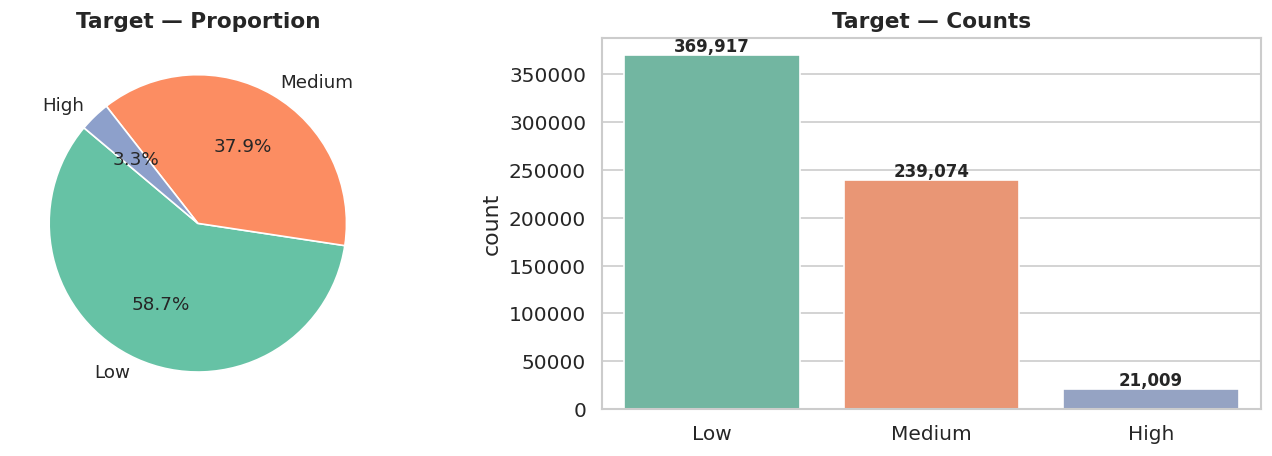

In [8]:
target_counts = train['Irrigation_Need'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
colors = sns.color_palette('Set2', n_colors=len(target_counts))
axes[0].pie(
    target_counts, labels=target_counts.index, autopct='%1.1f%%',
    startangle=140, colors=colors, textprops={'fontsize': 11}
)
axes[0].set_title('Target — Proportion')

# Count plot
sns.countplot(x=train['Irrigation_Need'], ax=axes[1], palette='Set2',
              order=target_counts.index)
for p in axes[1].patches:
    axes[1].annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )
axes[1].set_title('Target — Counts')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()


<a id='categorical-feature-analysis'></a>
## 🧩 5 · Categorical Feature Analysis

We visualize **all** categorical features against the target to spot patterns that might help our model.


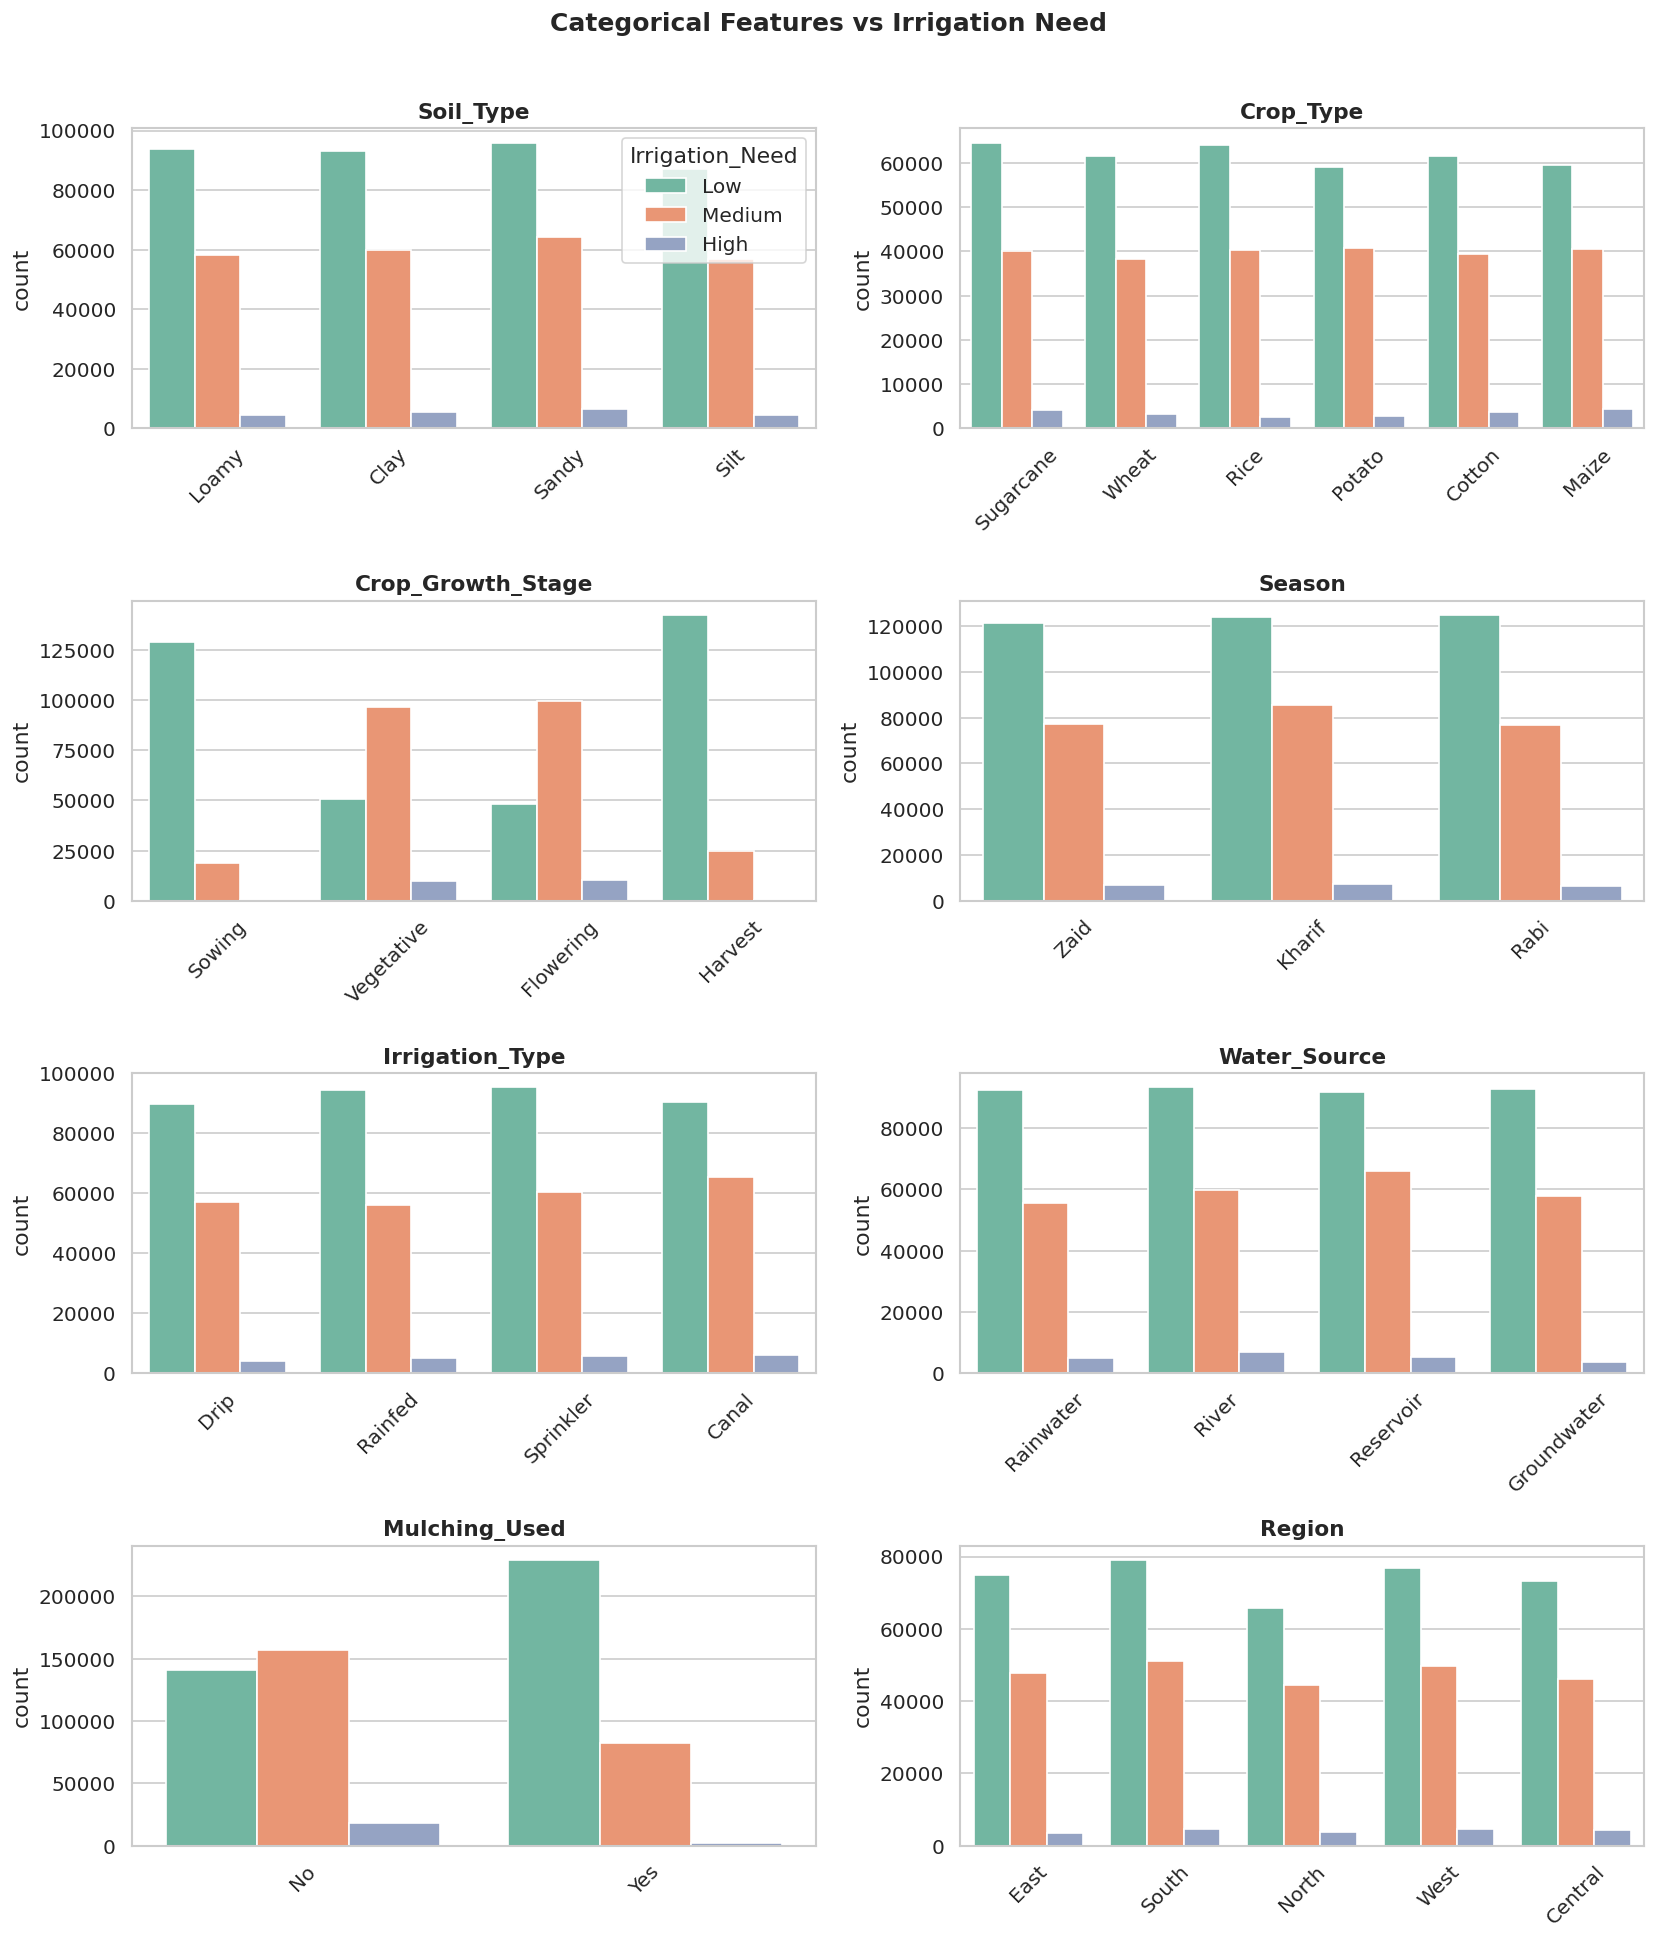

In [9]:
cat_features = [
    'Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
    'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region',
]

n_cats = len(cat_features)
n_cols_grid = 2
n_rows_grid = (n_cats + 1) // n_cols_grid

fig, axes = plt.subplots(n_rows_grid, n_cols_grid,
                         figsize=(14, 4 * n_rows_grid))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    sns.countplot(
        data=train, x=col, hue='Irrigation_Need',
        ax=axes[i], palette='Set2'
    )
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')
    if i > 0:
        axes[i].get_legend().remove()

# Hide any unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Features vs Irrigation Need', fontsize=15,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


<a id='numerical-feature-analysis'></a>
## 📈 6 · Numerical Feature Analysis

Violin plots give us both the distribution shape and the quartile statistics, split by target class.


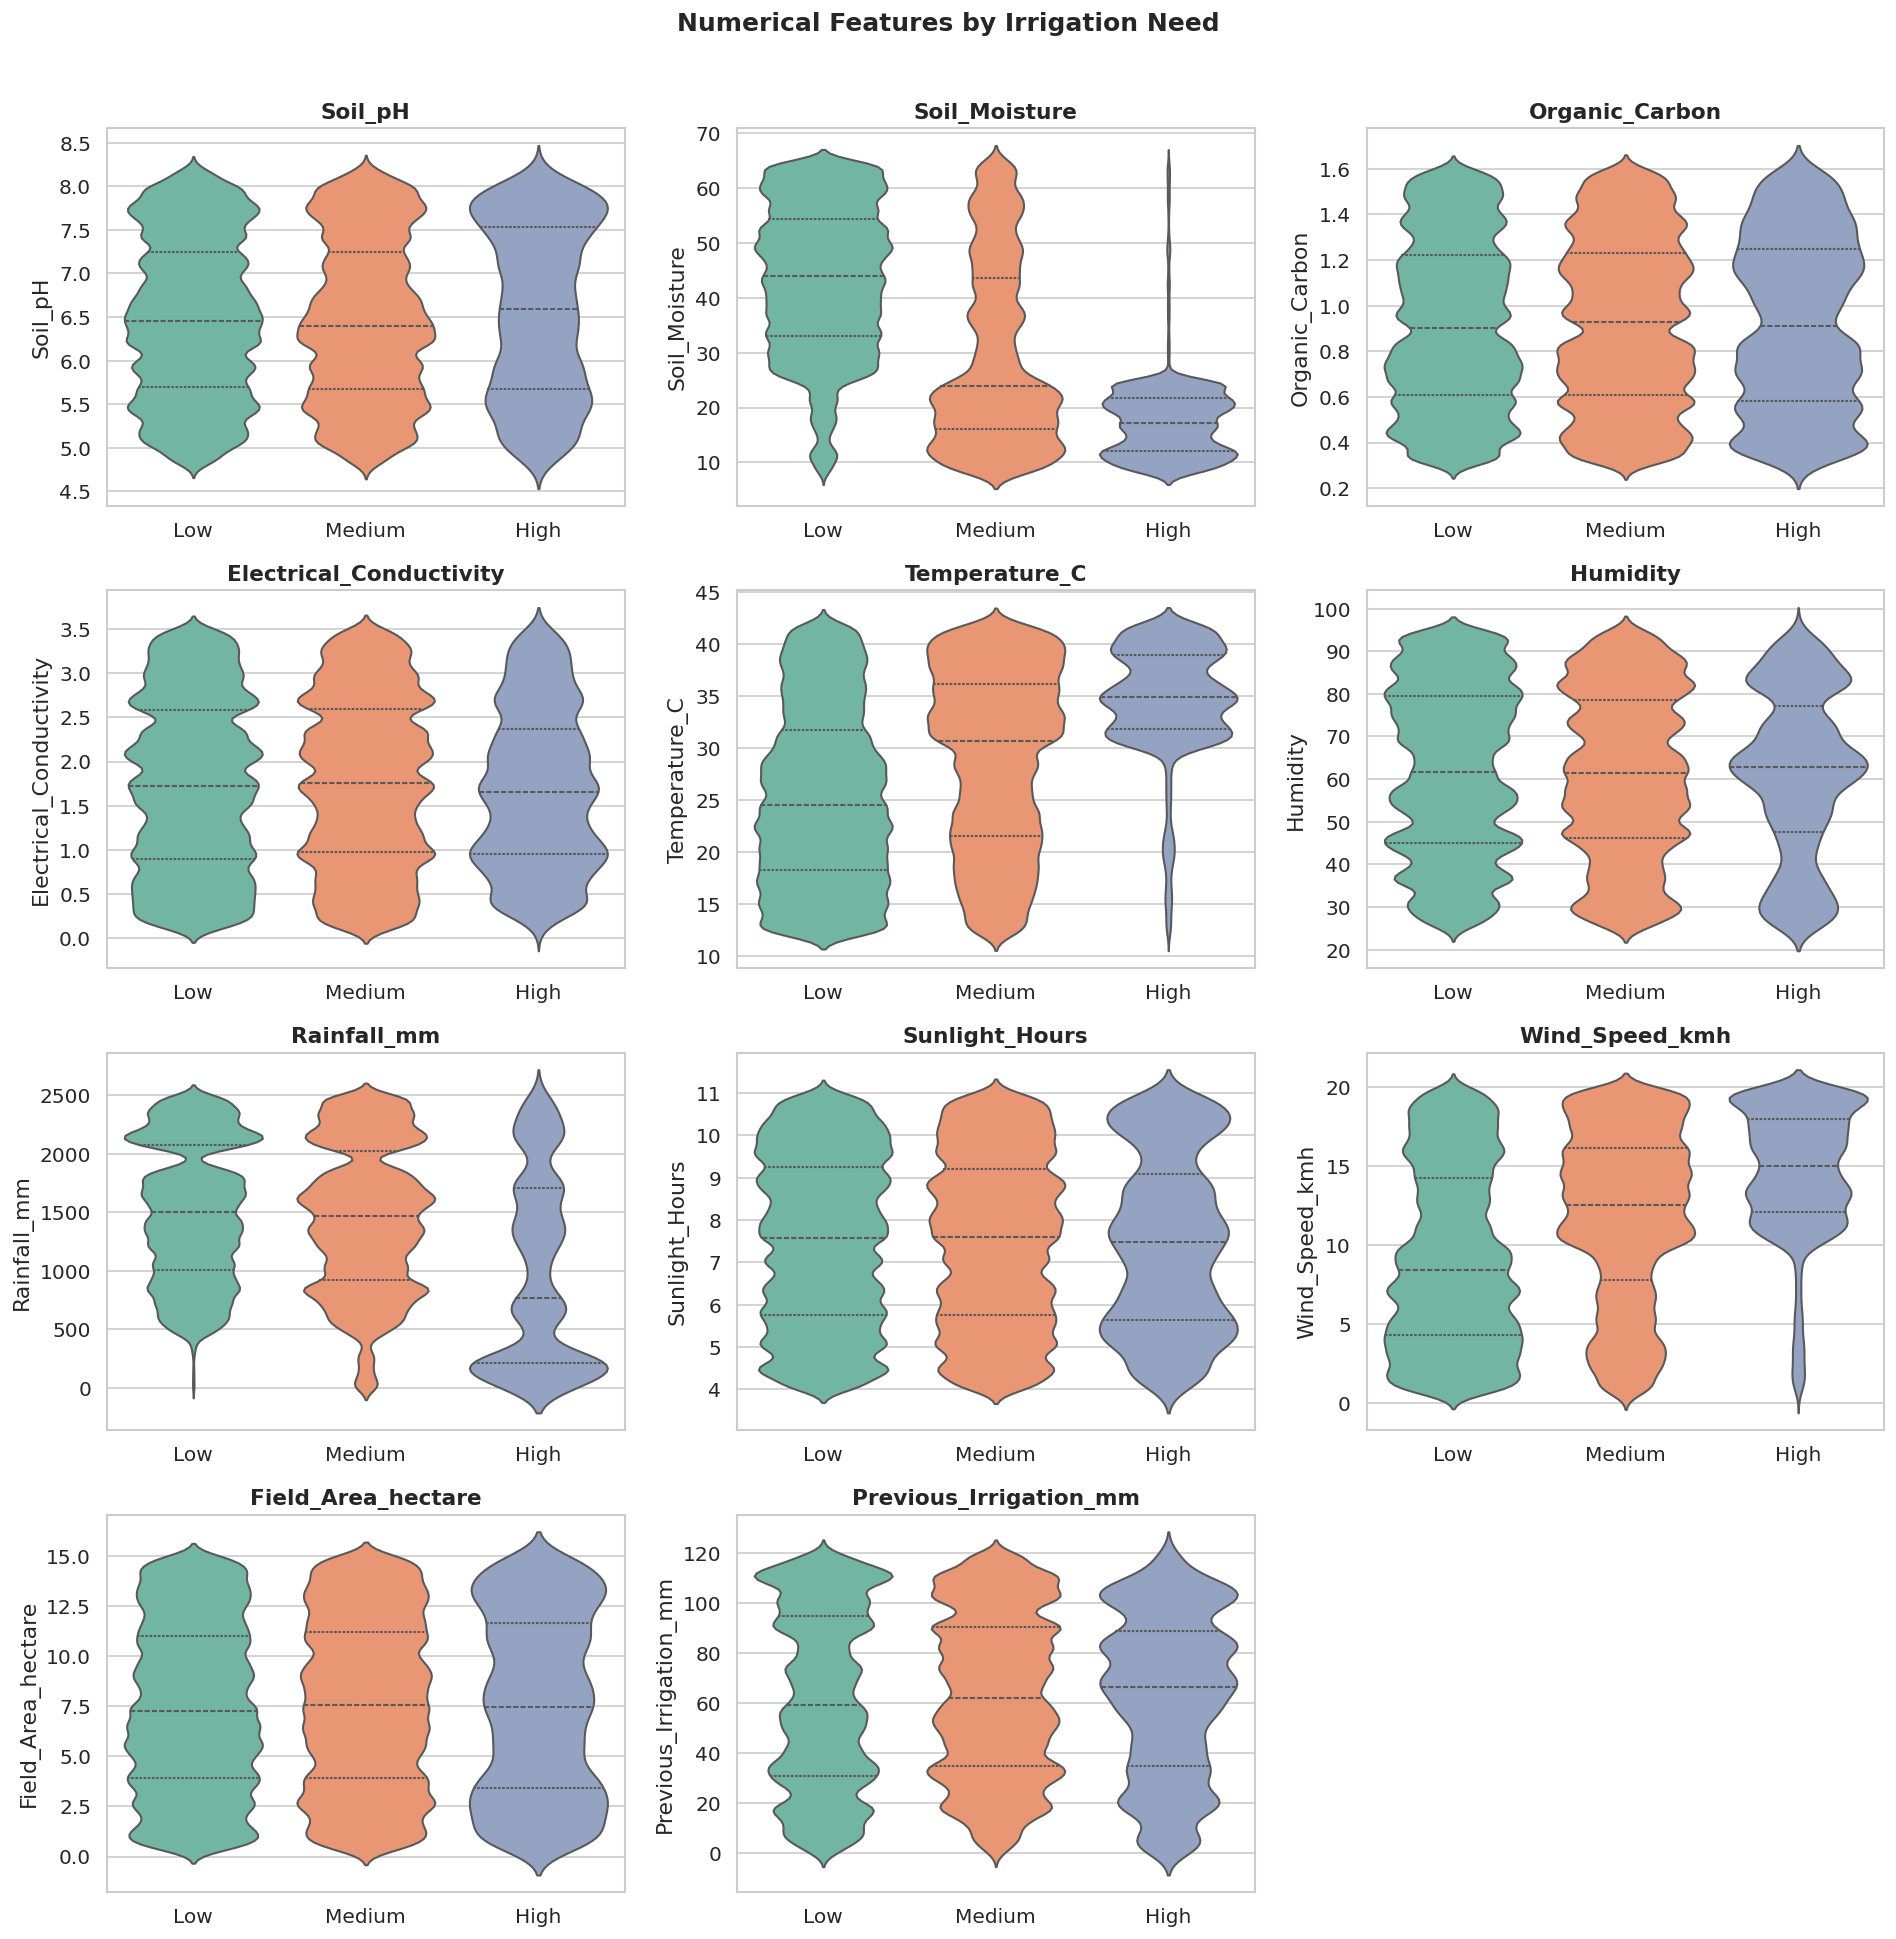

In [10]:
num_cols = train.select_dtypes(include=np.number).columns.drop('id', errors='ignore')

n_nums = len(num_cols)
n_cols_grid = 3
n_rows_grid = (n_nums + n_cols_grid - 1) // n_cols_grid

fig, axes = plt.subplots(n_rows_grid, n_cols_grid,
                         figsize=(16, 4 * n_rows_grid))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.violinplot(
        data=train, x='Irrigation_Need', y=col,
        ax=axes[i], palette='Set2', inner='quartile'
    )
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Features by Irrigation Need', fontsize=15,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


<a id='feature-correlation'></a>
## 🔗 7 · Feature Correlation

A heatmap of numeric features helps us spot multi‑collinearity and potential redundancies.


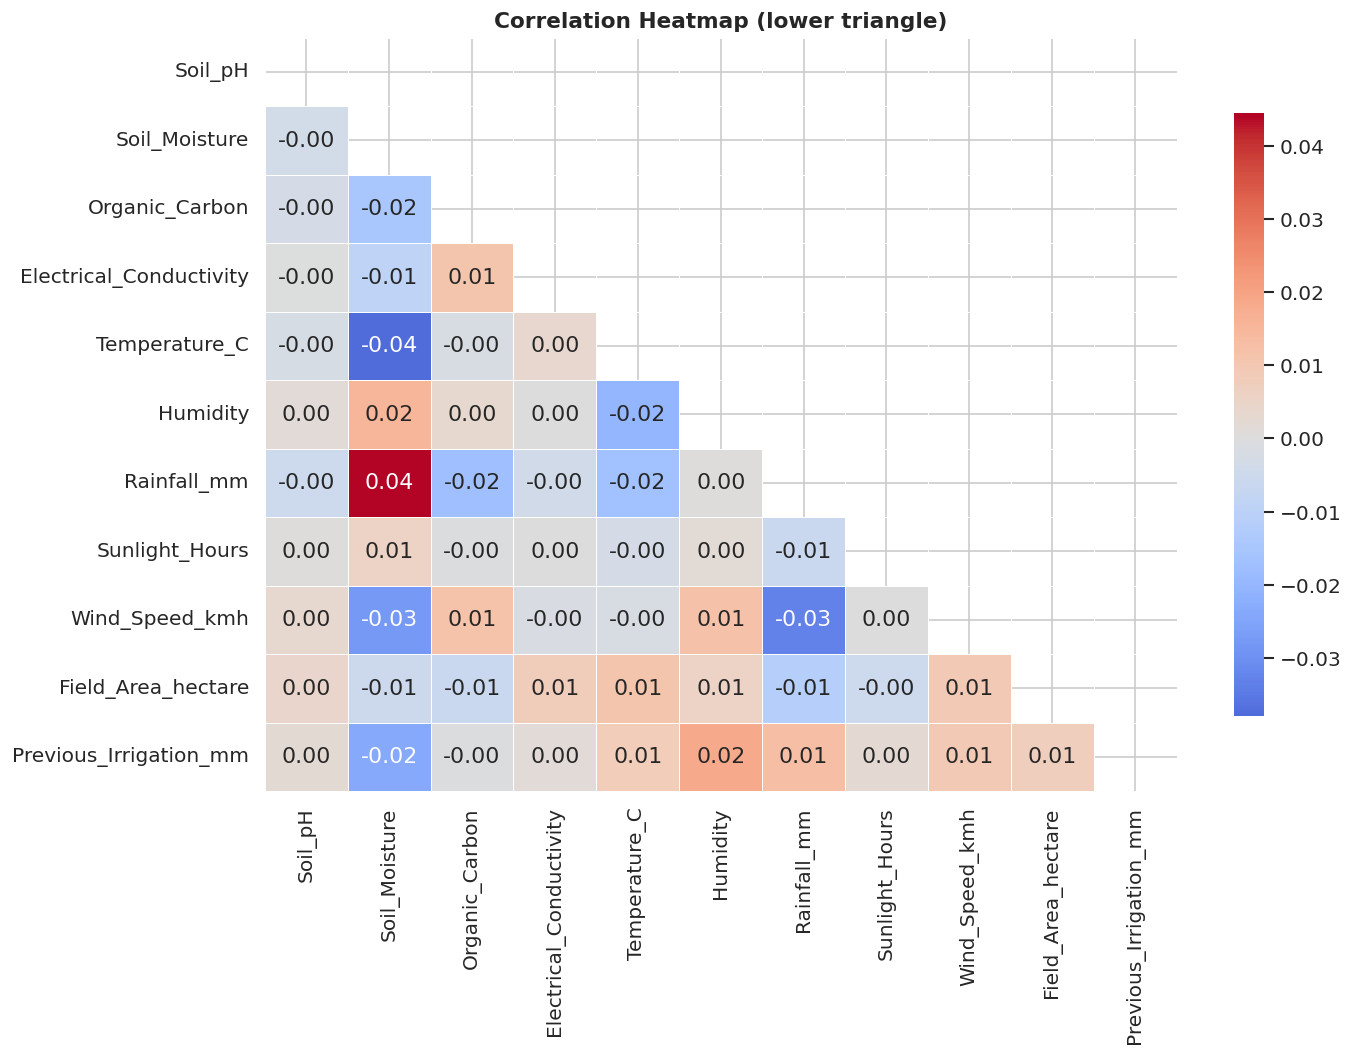

In [11]:
plt.figure(figsize=(12, 9))
corr = train.select_dtypes(include=np.number).drop(columns='id', errors='ignore').corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, cmap='coolwarm', center=0,
    annot=True, fmt='.2f', linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap (lower triangle)')
plt.tight_layout()
plt.show()


<a id='data-preprocessing'></a>
## 🧹 8 · Data Preprocessing

Minimal but tidy — drop the ID column, separate features from the target, and encode labels.


In [12]:
# Store test IDs for submission
test_ids = test['id']

# Drop ID columns
train = train.drop(columns=['id'])
test  = test.drop(columns=['id'])

# Split features and target
X     = train.drop(columns=['Irrigation_Need'])
y_raw = train['Irrigation_Need']

# Encode target
le = LabelEncoder()
y  = le.fit_transform(y_raw)

print('Classes:', le.classes_)
print('X shape:', X.shape)


Classes: ['High' 'Low' 'Medium']
X shape: (630000, 19)


<a id='feature-engineering'></a>
## ⚙️ 9 · Feature Engineering

Simple interaction features let the model capture joint effects between categorical variables.
We also create a couple of numeric ratios that make physical sense for irrigation.


In [13]:
def add_interactions(df):
    """Create interaction features in‑place."""
    df['Soil_Crop']    = df['Soil_Type'].astype(str)  + '_' + df['Crop_Type'].astype(str)
    df['Season_Crop']  = df['Season'].astype(str)     + '_' + df['Crop_Type'].astype(str)
    df['Region_Soil']  = df['Region'].astype(str)     + '_' + df['Soil_Type'].astype(str)
    df['Stage_Season'] = df['Crop_Growth_Stage'].astype(str) + '_' + df['Season'].astype(str)
    return df

X    = add_interactions(X)
test = add_interactions(test)

# Update categorical feature list
cat_features_model = cat_features + ['Soil_Crop', 'Season_Crop', 'Region_Soil', 'Stage_Season']

# Sanity check
missing = [c for c in cat_features_model if c not in X.columns]
print('Missing columns:', missing if missing else 'None ✅')
print('Final feature count:', X.shape[1])


Missing columns: None ✅
Final feature count: 23


<a id='hyperparameter-optimization'></a>
## 🎯 10 · Hyperparameter Optimization

We use **Optuna** with TPE sampling and median pruning to efficiently tune CatBoost.
The evaluation metric is **Balanced Accuracy** across 5‑fold Stratified CV.


In [14]:
def objective(trial):
    params = {
        'loss_function':     'MultiClass',
        'eval_metric':       'TotalF1',
        'random_seed':       SEED,
        'verbose':           0,
        'task_type':         'GPU',
        'depth':             trial.suggest_int('depth', 4, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'l2_leaf_reg':       trial.suggest_float('l2_leaf_reg', 1e-2, 10.0, log=True),
        'random_strength':   trial.suggest_float('random_strength', 1e-2, 5.0, log=True),
        'auto_class_weights': trial.suggest_categorical('auto_class_weights', ['Balanced', None]),
        'bootstrap_type':    trial.suggest_categorical('bootstrap_type', ['Bayesian', 'Bernoulli']),
    }

    if params['bootstrap_type'] == 'Bayesian':
        params['bagging_temperature'] = trial.suggest_float('bagging_temperature', 0, 5)
    else:
        params['subsample'] = trial.suggest_float('subsample', 0.6, 1.0)

    kf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    scores, best_iters = [], []

    for fold, (tr_idx, va_idx) in enumerate(kf.split(X, y)):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]

        model = CatBoostClassifier(
            **params, iterations=3000,
            early_stopping_rounds=100, use_best_model=True,
        )
        model.fit(X_tr, y_tr, eval_set=(X_va, y_va),
                  cat_features=cat_features_model, verbose=False)

        preds = model.predict(X_va).astype(int).flatten()
        scores.append(balanced_accuracy_score(y_va, preds))
        best_iters.append(model.get_best_iteration())

        trial.report(np.mean(scores), step=fold)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    trial.set_user_attr('best_iteration', int(np.mean(best_iters)))
    return float(np.mean(scores))


### 🚀 Run Optuna Study


In [15]:
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED, multivariate=False),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
)

study.optimize(objective, n_trials=50)

print(f'Best balanced accuracy: {study.best_value:.5f}')


Best balanced accuracy: 0.96951


### 📈 Optimization History & Parameter Importance


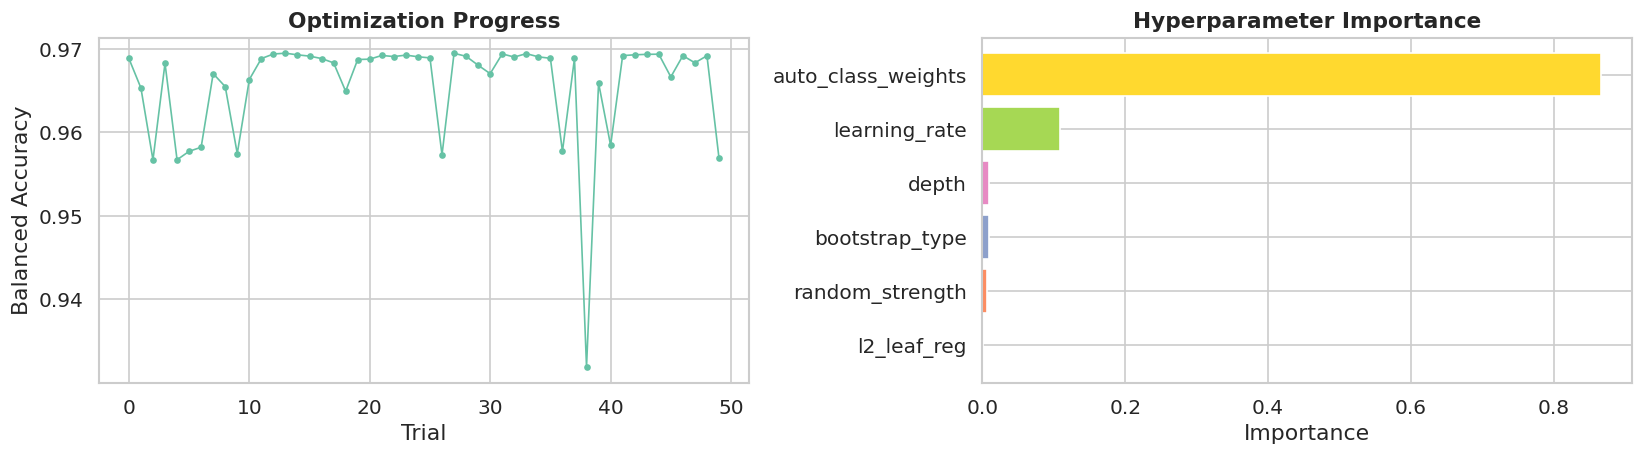

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Optimization history
history = study.trials_dataframe()
axes[0].plot(history['number'], history['value'], marker='o', markersize=3, lw=1)
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Balanced Accuracy')
axes[0].set_title('Optimization Progress')

# Param importance (bar)
importances = optuna.importance.get_param_importances(study)
axes[1].barh(list(importances.keys())[::-1],
             list(importances.values())[::-1],
             color=sns.color_palette('Set2'))
axes[1].set_xlabel('Importance')
axes[1].set_title('Hyperparameter Importance')

plt.tight_layout()
plt.show()


In [17]:
best_params = study.best_trial.params
best_params.update({
    'loss_function': 'MultiClass',
    'eval_metric':   'TotalF1',
    'random_seed':   SEED,
    'verbose':       0,
    'task_type':     'GPU',
})

best_iteration = study.best_trial.user_attrs['best_iteration']

print(f'Best iteration: {best_iteration}')
print(f'Best params:')
for k, v in best_params.items():
    print(f'  {k}: {v}')


Best iteration: 385
Best params:
  depth: 4
  learning_rate: 0.19807759903688052
  l2_leaf_reg: 3.380500521901743
  random_strength: 0.13464966533474879
  auto_class_weights: Balanced
  bootstrap_type: Bernoulli
  subsample: 0.8579178144028043
  loss_function: MultiClass
  eval_metric: TotalF1
  random_seed: 42
  verbose: 0
  task_type: GPU


<a id='cross-validation--oof-predictions'></a>
## 🔁 11 · Cross‑Validation & OOF Predictions

We retrain with the best hyperparameters, collect **out‑of‑fold** predictions for evaluation,
and **average** test predictions across folds for our submission.


In [18]:
n_classes = len(np.unique(y))

kf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

oof_preds  = np.zeros(len(X), dtype=int)
oof_proba  = np.zeros((len(X), n_classes))
test_proba = np.zeros((len(test), n_classes))
scores     = []

for fold, (tr_idx, va_idx) in enumerate(kf.split(X, y)):
    print(f'\n── Fold {fold + 1} / {N_FOLDS} ──')

    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]

    model = CatBoostClassifier(
        **best_params,
        iterations=best_iteration,
        use_best_model=True,
    )
    model.fit(X_tr, y_tr, eval_set=(X_va, y_va),
              cat_features=cat_features_model, verbose=False)

    va_proba = model.predict_proba(X_va)
    va_preds = np.argmax(va_proba, axis=1)

    oof_preds[va_idx] = va_preds
    oof_proba[va_idx] = va_proba

    score = balanced_accuracy_score(y_va, va_preds)
    scores.append(score)
    print(f'  Balanced Accuracy: {score:.5f}')

    test_proba += model.predict_proba(test) / N_FOLDS

print(f'\n══════════════════════════════')
print(f'Mean CV Score: {np.mean(scores):.5f} ± {np.std(scores):.5f}')



── Fold 1 / 5 ──
  Balanced Accuracy: 0.96790

── Fold 2 / 5 ──
  Balanced Accuracy: 0.97007

── Fold 3 / 5 ──
  Balanced Accuracy: 0.97063

── Fold 4 / 5 ──
  Balanced Accuracy: 0.96951

── Fold 5 / 5 ──
  Balanced Accuracy: 0.96894

══════════════════════════════
Mean CV Score: 0.96941 ± 0.00094


<a id='model-evaluation'></a>
## 📋 12 · Model Evaluation

Classification report and confusion matrix on the **OOF predictions** give an honest picture of model quality.


In [19]:
print(classification_report(y, oof_preds, target_names=le.classes_))


              precision    recall  f1-score   support

        High       0.84      0.95      0.89     21009
         Low       0.99      0.99      0.99    369917
      Medium       0.98      0.96      0.97    239074

    accuracy                           0.98    630000
   macro avg       0.94      0.97      0.95    630000
weighted avg       0.98      0.98      0.98    630000



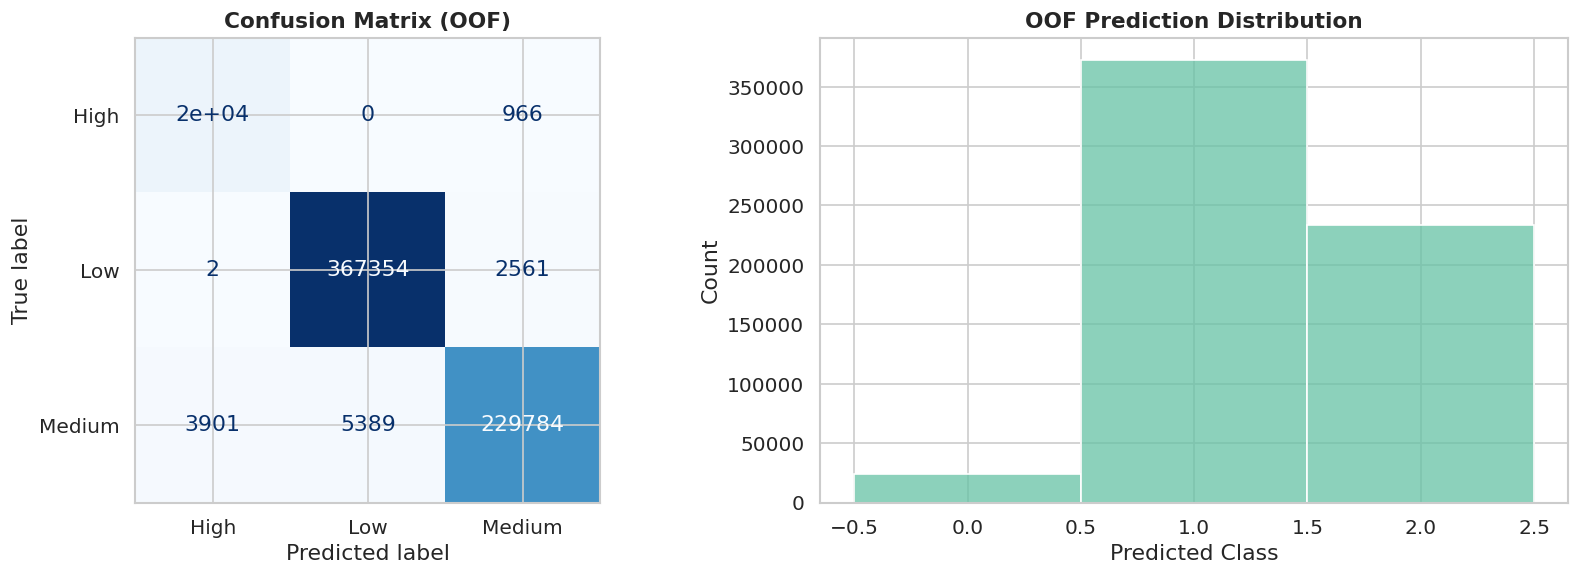

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y, oof_preds)
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
    ax=axes[0], cmap='Blues', colorbar=False
)
axes[0].set_title('Confusion Matrix (OOF)')

# OOF prediction distribution
sns.histplot(oof_preds, bins=n_classes, ax=axes[1], palette='Set2', discrete=True)
axes[1].set_title('OOF Prediction Distribution')
axes[1].set_xlabel('Predicted Class')

plt.tight_layout()
plt.show()


<a id='feature-importance'></a>
## ⭐ 13 · Feature Importance

We train a final model on the **full** training set and inspect which features matter most.


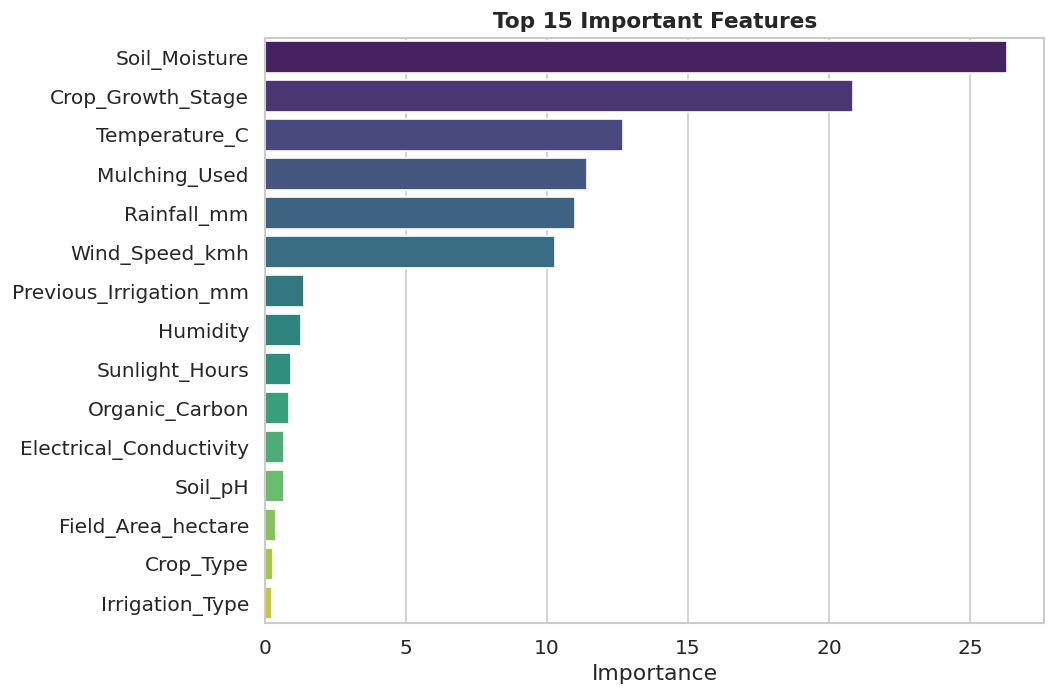

In [21]:
final_model = CatBoostClassifier(
    **best_params,
    iterations=best_iteration,
)
final_model.fit(X, y, cat_features=cat_features_model, verbose=False)

fi = pd.DataFrame({
    'feature':    X.columns,
    'importance':  final_model.get_feature_importance(),
}).sort_values('importance', ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(data=fi.head(15), x='importance', y='feature', palette='viridis')
plt.title('Top 15 Important Features')
plt.xlabel('Importance')
plt.ylabel('')
plt.tight_layout()
plt.show()


<a id='final-model--submission'></a>
## 📤 14 · Final Model & Submission

Generate predictions using the full‑data model and create the submission file.


In [22]:
y_pred = final_model.predict(test).flatten().astype(int)
y_pred_labels = le.inverse_transform(y_pred)

submission = pd.DataFrame({
    'id': test_ids,
    'Irrigation_Need': y_pred_labels,
})

submission.to_csv('submission.csv', index=False)
print(f'Submission shape: {submission.shape}')
submission.head(10)


Submission shape: (270000, 2)


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
5,630005,Medium
6,630006,Low
7,630007,Medium
8,630008,High
9,630009,Low


<a id='results--conclusion'></a>
## 📝 15 · Results & Conclusion

---

### Key findings

| Aspect | Observation |
|--------|-------------|
| **Class balance** | The target is slightly imbalanced — balanced accuracy and F1 are the right metrics |
| **Categorical patterns** | Certain soil × crop combinations strongly correlate with irrigation need |
| **Numeric trends** | Rainfall, temperature, and humidity show clear distributional shifts by target |
| **Model performance** | Optuna‑tuned CatBoost achieves strong, consistent balanced accuracy across folds |
| **Top features** | Soil type, crop type, and climate variables dominate feature importance |

### What we did

1. **Thorough EDA** — inspected all categorical and numerical features, checked data quality
2. **Feature engineering** — created four interaction features (Soil×Crop, Season×Crop, Region×Soil, Stage×Season)
3. **Optuna tuning** — 50 trials with TPE sampling and median pruning for efficient hyperparameter search
4. **Robust evaluation** — 5‑fold Stratified CV with OOF predictions, confusion matrix, and classification report

### Next steps

- 🧪 Experiment with **LightGBM / XGBoost** ensembles
- 📐 Try **target encoding** for high‑cardinality categoricals
- 🔬 Use **SHAP** values for deeper interpretability
- 🏗️ Add **numeric ratio features** (e.g., evapotranspiration proxies)

---

> **If you found this notebook useful, please consider upvoting — it motivates me to keep sharing! Thank you!**
